In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
class Perceptron:
    def __init__(self, df):
        self.n_datapoints = df.shape[0]
        self.x = df.loc[:, df.columns!='y']
        self.d_features = self.x.shape[1]
        self.y = df['y']
        self.W = np.array([1 for _ in range(self.d_features+1)])
        self.x.insert(0, 'x0', 1)
    
    def display_attr(self):
        print(self.n_datapoints, self.d_features)
        print(self.W)

    def sig_activate(self, y_hat):
        return 1/(1+np.exp(-y_hat))
    
    def build_model(self):
        Wold = W = self.W
        epochs = 0
        n_datapoints = self.n_datapoints
        d_features = self.d_features
        x = self.x
        y = self.y
        eta = 0.05
        lb = 0.01
        
        print(f"The Learning Rate is {eta}")
        print(f"The initial Weights are {Wold}")
        
        while True:
            if epochs!=0:
                Wold = W
            
            print(f"Running Epoch {epochs+1} ===========", end='')
            
            for i in range(n_datapoints):                
                x_vec = x.iloc[i]
                wTx = W.T.dot(x_vec)
                
                y_true = y.iloc[i]
                y_hat = self.sig_activate(wTx)
                
                # SSE Loss L2 - regularized
                W = W - eta*((y_true-y_hat)*y_hat*(1-y_hat)*np.array(x_vec)+lb*W)
            
            epochs += 1
            print("==>")
            print(f"Old Weights {Wold}")
            print(f"New Weights: {W}")
            
            if np.allclose(W, Wold):
                break
        
        self.W = W
        print("Model Building done., Hyperplane weights optimized.")
    
    def plot_graph(self, W):
        w0, w1, w2 = W
        x = self.x
        y = self.y
        x1 = np.linspace(-2, 2, 100)
        x2 = (-w0-w1*x1)/w2


        plt.scatter(x['x1'], x['x2'], c=y, cmap='coolwarm')
        plt.plot(x1, x2, '-r')
        plt.legend(['Datapoints', 'Hyperplane - (wTx = 0)'])
        plt.show()

In [30]:
or_df = pd.DataFrame({'x1':[0, 0, 1, 1], 'x2':[0, 1, 0, 1], 'y':[0, 1, 1, 1]})

In [31]:
p1 = Perceptron(or_df)

In [32]:
p1.display_attr()

4 2
[1 1 1]


In [33]:
p1.W*0.5 + 1

array([1.5, 1.5, 1.5])

In [34]:
p1.build_model()

The Learning Rate is 0.05
The initial Weights are [1 1 1]
Running Epoch 1 =============>
Old Weights [1 1 1]
New Weights: [1.00383076 0.99727362 0.99727558]
Running Epoch 2 =============>
Old Weights [1.00383076 0.99727362 0.99727558]
New Weights: [1.00765044 0.99455349 0.99455741]
Running Epoch 3 =============>
Old Weights [1.00765044 0.99455349 0.99455741]
New Weights: [1.01145901 0.99183958 0.99184546]
Running Epoch 4 =============>
Old Weights [1.01145901 0.99183958 0.99184546]
New Weights: [1.01525644 0.98913189 0.98913971]
Running Epoch 5 =============>
Old Weights [1.01525644 0.98913189 0.98913971]
New Weights: [1.01904269 0.98643038 0.98644014]
Running Epoch 6 =============>
Old Weights [1.01904269 0.98643038 0.98644014]
New Weights: [1.02281772 0.98373503 0.98374673]
Running Epoch 7 =============>
Old Weights [1.02281772 0.98373503 0.98374673]
New Weights: [1.02658152 0.98104584 0.98105946]
Running Epoch 8 =============>
Old Weights [1.02658152 0.98104584 0.98105946]
New Weigh

Running Epoch 649 =============>
Old Weights [ 1.3557669  -0.42238176 -0.42070418]
New Weights: [ 1.34943656 -0.42879525 -0.42710325]
Running Epoch 650 =============>
Old Weights [ 1.34943656 -0.42879525 -0.42710325]
New Weights: [ 1.34297651 -0.4353122  -0.43360549]
Running Epoch 651 =============>
Old Weights [ 1.34297651 -0.4353122  -0.43360549]
New Weights: [ 1.33638365 -0.44193488 -0.44021316]
Running Epoch 652 =============>
Old Weights [ 1.33638365 -0.44193488 -0.44021316]
New Weights: [ 1.32965484 -0.44866556 -0.44692854]
Running Epoch 653 =============>
Old Weights [ 1.32965484 -0.44866556 -0.44692854]
New Weights: [ 1.32278694 -0.45550653 -0.4537539 ]
Running Epoch 654 =============>
Old Weights [ 1.32278694 -0.45550653 -0.4537539 ]
New Weights: [ 1.31577673 -0.46246008 -0.46069151]
Running Epoch 655 =============>
Old Weights [ 1.31577673 -0.46246008 -0.46069151]
New Weights: [ 1.30862101 -0.46952847 -0.46774364]
Running Epoch 656 =============>
Old Weights [ 1.30862101 -0.4

Running Epoch 974 =============>
Old Weights [-0.74052346 -1.82515191 -1.8250055 ]
New Weights: [-0.74228499 -1.82518362 -1.82504069]
Running Epoch 975 =============>
Old Weights [-0.74228499 -1.82518362 -1.82504069]
New Weights: [-0.74403966 -1.82520987 -1.8250704 ]
Running Epoch 976 =============>
Old Weights [-0.74403966 -1.82520987 -1.8250704 ]
New Weights: [-0.74578753 -1.82523074 -1.8250947 ]
Running Epoch 977 =============>
Old Weights [-0.74578753 -1.82523074 -1.8250947 ]
New Weights: [-0.74752866 -1.82524628 -1.82511363]
Running Epoch 978 =============>
Old Weights [-0.74752866 -1.82524628 -1.82511363]
New Weights: [-0.74926312 -1.82525654 -1.82512726]
Running Epoch 979 =============>
Old Weights [-0.74926312 -1.82525654 -1.82512726]
New Weights: [-0.75099096 -1.82526158 -1.82513563]
Running Epoch 980 =============>
Old Weights [-0.75099096 -1.82526158 -1.82513563]
New Weights: [-0.75271226 -1.82526145 -1.82513881]
Running Epoch 981 =============>
Old Weights [-0.75271226 -1.8

Running Epoch 1302 =============>
Old Weights [-1.13488254 -1.71245148 -1.71266509]
New Weights: [-1.13579159 -1.71198864 -1.71220228]
Running Epoch 1303 =============>
Old Weights [-1.13579159 -1.71198864 -1.71220228]
New Weights: [-1.13669958 -1.71152582 -1.71173949]
Running Epoch 1304 =============>
Old Weights [-1.13669958 -1.71152582 -1.71173949]
New Weights: [-1.13760651 -1.71106302 -1.71127671]
Running Epoch 1305 =============>
Old Weights [-1.13760651 -1.71106302 -1.71127671]
New Weights: [-1.13851237 -1.71060025 -1.71081396]
Running Epoch 1306 =============>
Old Weights [-1.13851237 -1.71060025 -1.71081396]
New Weights: [-1.13941719 -1.7101375  -1.71035123]
Running Epoch 1307 =============>
Old Weights [-1.13941719 -1.7101375  -1.71035123]
New Weights: [-1.14032095 -1.70967478 -1.70988852]
Running Epoch 1308 =============>
Old Weights [-1.14032095 -1.70967478 -1.70988852]
New Weights: [-1.14122366 -1.70921209 -1.70942584]
Running Epoch 1309 =============>
Old Weights [-1.14122

Running Epoch 1651 =============>
Old Weights [-1.39767433 -1.56351226 -1.56366076]
New Weights: [-1.39828825 -1.56313945 -1.56328768]
Running Epoch 1652 =============>
Old Weights [-1.39828825 -1.56313945 -1.56328768]
New Weights: [-1.39890144 -1.56276699 -1.56291496]
Running Epoch 1653 =============>
Old Weights [-1.39890144 -1.56276699 -1.56291496]
New Weights: [-1.39951392 -1.56239488 -1.56254259]
Running Epoch 1654 =============>
Old Weights [-1.39951392 -1.56239488 -1.56254259]
New Weights: [-1.40012567 -1.56202313 -1.56217057]
Running Epoch 1655 =============>
Old Weights [-1.40012567 -1.56202313 -1.56217057]
New Weights: [-1.4007367  -1.56165174 -1.5617989 ]
Running Epoch 1656 =============>
Old Weights [-1.4007367  -1.56165174 -1.5617989 ]
New Weights: [-1.40134701 -1.56128069 -1.56142759]
Running Epoch 1657 =============>
Old Weights [-1.40134701 -1.56128069 -1.56142759]
New Weights: [-1.40195661 -1.56091    -1.56105663]
Running Epoch 1658 =============>
Old Weights [-1.40195

Running Epoch 2310 =============>
Old Weights [-1.67188666 -1.38945939 -1.38946778]
New Weights: [-1.6721441  -1.38928934 -1.38929759]
Running Epoch 2311 =============>
Old Weights [-1.6721441  -1.38928934 -1.38929759]
New Weights: [-1.67240118 -1.38911952 -1.38912763]
Running Epoch 2312 =============>
Old Weights [-1.67240118 -1.38911952 -1.38912763]
New Weights: [-1.67265789 -1.38894993 -1.3889579 ]
Running Epoch 2313 =============>
Old Weights [-1.67265789 -1.38894993 -1.3889579 ]
New Weights: [-1.67291424 -1.38878057 -1.3887884 ]
Running Epoch 2314 =============>
Old Weights [-1.67291424 -1.38878057 -1.3887884 ]
New Weights: [-1.67317022 -1.38861144 -1.38861913]
Running Epoch 2315 =============>
Old Weights [-1.67317022 -1.38861144 -1.38861913]
New Weights: [-1.67342584 -1.38844254 -1.38845009]
Running Epoch 2316 =============>
Old Weights [-1.67342584 -1.38844254 -1.38845009]
New Weights: [-1.67368109 -1.38827387 -1.38828128]
Running Epoch 2317 =============>
Old Weights [-1.67368

Running Epoch 2625 =============>
Old Weights [-1.7370974  -1.34600497 -1.34597778]
New Weights: [-1.7372603  -1.34589546 -1.34586818]
Running Epoch 2626 =============>
Old Weights [-1.7372603  -1.34589546 -1.34586818]
New Weights: [-1.73742297 -1.34578611 -1.34575874]
Running Epoch 2627 =============>
Old Weights [-1.73742297 -1.34578611 -1.34575874]
New Weights: [-1.7375854  -1.34567692 -1.34564946]
Running Epoch 2628 =============>
Old Weights [-1.7375854  -1.34567692 -1.34564946]
New Weights: [-1.73774759 -1.34556788 -1.34554033]
Running Epoch 2629 =============>
Old Weights [-1.73774759 -1.34556788 -1.34554033]
New Weights: [-1.73790954 -1.345459   -1.34543137]
Running Epoch 2630 =============>
Old Weights [-1.73790954 -1.345459   -1.34543137]
New Weights: [-1.73807125 -1.34535027 -1.34532255]
Running Epoch 2631 =============>
Old Weights [-1.73807125 -1.34535027 -1.34532255]
New Weights: [-1.73823272 -1.34524171 -1.3452139 ]
Running Epoch 2632 =============>
Old Weights [-1.73823

Running Epoch 3063 =============>
Old Weights [-1.7895277  -1.31052112 -1.31046577]
New Weights: [-1.7896122  -1.31046355 -1.31040816]
Running Epoch 3064 =============>
Old Weights [-1.7896122  -1.31046355 -1.31040816]
New Weights: [-1.78969657 -1.31040606 -1.31035063]
Running Epoch 3065 =============>
Old Weights [-1.78969657 -1.31040606 -1.31035063]
New Weights: [-1.78978081 -1.31034867 -1.31029319]
Running Epoch 3066 =============>
Old Weights [-1.78978081 -1.31034867 -1.31029319]
New Weights: [-1.78986492 -1.31029135 -1.31023583]
Running Epoch 3067 =============>
Old Weights [-1.78986492 -1.31029135 -1.31023583]
New Weights: [-1.78994891 -1.31023413 -1.31017856]
Running Epoch 3068 =============>
Old Weights [-1.78994891 -1.31023413 -1.31017856]
New Weights: [-1.79003277 -1.31017699 -1.31012137]
Running Epoch 3069 =============>
Old Weights [-1.79003277 -1.31017699 -1.31012137]
New Weights: [-1.7901165  -1.31011993 -1.31006427]
Running Epoch 3070 =============>
Old Weights [-1.79011

Running Epoch 3431 =============>
Old Weights [-1.81335219 -1.29424087 -1.29417301]
New Weights: [-1.81340039 -1.29420784 -1.29413995]
Running Epoch 3432 =============>
Old Weights [-1.81340039 -1.29420784 -1.29413995]
New Weights: [-1.81344851 -1.29417486 -1.29410694]
Running Epoch 3433 =============>
Old Weights [-1.81344851 -1.29417486 -1.29410694]
New Weights: [-1.81349656 -1.29414193 -1.29407399]
Running Epoch 3434 =============>
Old Weights [-1.81349656 -1.29414193 -1.29407399]
New Weights: [-1.81354453 -1.29410905 -1.29404108]
Running Epoch 3435 =============>
Old Weights [-1.81354453 -1.29410905 -1.29404108]
New Weights: [-1.81359244 -1.29407622 -1.29400822]
Running Epoch 3436 =============>
Old Weights [-1.81359244 -1.29407622 -1.29400822]
New Weights: [-1.81364026 -1.29404344 -1.29397542]
Running Epoch 3437 =============>
Old Weights [-1.81364026 -1.29404344 -1.29397542]
New Weights: [-1.81368802 -1.29401071 -1.29394266]
Running Epoch 3438 =============>
Old Weights [-1.81368

Running Epoch 3750 =============>
Old Weights [-1.82551524 -1.28589264 -1.28581847]
New Weights: [-1.82554475 -1.28587236 -1.28579817]
Running Epoch 3751 =============>
Old Weights [-1.82554475 -1.28587236 -1.28579817]
New Weights: [-1.82557421 -1.28585211 -1.28577791]
Running Epoch 3752 =============>
Old Weights [-1.82557421 -1.28585211 -1.28577791]
New Weights: [-1.82560362 -1.28583189 -1.28575767]
Running Epoch 3753 =============>
Old Weights [-1.82560362 -1.28583189 -1.28575767]
New Weights: [-1.825633   -1.2858117  -1.28573747]
Running Epoch 3754 =============>
Old Weights [-1.825633   -1.2858117  -1.28573747]
New Weights: [-1.82566232 -1.28579154 -1.2857173 ]
Running Epoch 3755 =============>
Old Weights [-1.82566232 -1.28579154 -1.2857173 ]
New Weights: [-1.8256916  -1.28577141 -1.28569715]
Running Epoch 3756 =============>
Old Weights [-1.8256916  -1.28577141 -1.28569715]
New Weights: [-1.82572084 -1.28575132 -1.28567704]
Running Epoch 3757 =============>
Old Weights [-1.82572

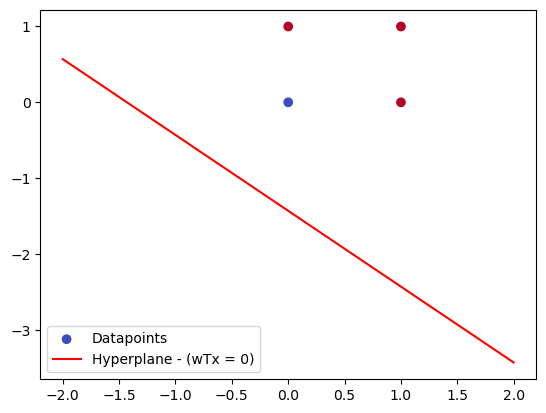

In [35]:
p1.plot_graph(p1.W)

In [39]:
# IRIS Dataset.
from sklearn.datasets import load_iris

In [40]:
iris = load_iris()

In [41]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.DataFrame(iris.target, columns=['y'])

In [42]:
df = pd.DataFrame(X)
df['y'] = y

In [43]:
df = df[:100]

In [44]:
p3 = Perceptron(df)

In [45]:
p3.x

,x0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,1,5.1,3.5,1.4,0.2
1,1,4.9,3.0,1.4,0.2
2,1,4.7,3.2,1.3,0.2
3,1,4.6,3.1,1.5,0.2
4,1,5.0,3.6,1.4,0.2
...,...,...,...,...,...
95,1,5.7,3.0,4.2,1.2
96,1,5.7,2.9,4.2,1.3
97,1,6.2,2.9,4.3,1.3
98,1,5.1,2.5,3.0,1.1


In [46]:
p3.build_model()

The Learning Rate is 0.05
The initial Weights are [1 1 1 1 1]
Running Epoch 1 =============>
Old Weights [1 1 1 1 1]
New Weights: [0.95127117 0.95147349 0.95138793 0.95129218 0.95122929]
Running Epoch 2 =============>
Old Weights [0.95127117 0.95147349 0.95138793 0.95129218 0.95122929]
New Weights: [0.90495484 0.90548397 0.90526071 0.90501    0.90484557]
Running Epoch 3 =============>
Old Weights [0.90495484 0.90548397 0.90526071 0.90501    0.90484557]
New Weights: [0.86095296 0.86200258 0.8615608  0.86106287 0.86073679]
Running Epoch 4 =============>
Old Weights [0.86095296 0.86200258 0.8615608  0.86106287 0.86073679]
New Weights: [0.81918091 0.82104375 0.8202617  0.81937684 0.81879835]
Running Epoch 5 =============>
Old Weights [0.81918091 0.82104375 0.8202617  0.81937684 0.81879835]
New Weights: [0.77956917 0.78267479 0.78137437 0.77989727 0.77893323]
Running Epoch 6 =============>
Old Weights [0.77956917 0.78267479 0.78137437 0.77989727 0.77893323]
New Weights: [0.74206473 0.747023

Running Epoch 59 =============>
Old Weights [0.18872324 0.7063957  0.49496753 0.24627293 0.08587065]
New Weights: [0.18681281 0.70746512 0.49482195 0.24470202 0.08337115]
Running Epoch 60 =============>
Old Weights [0.18681281 0.70746512 0.49482195 0.24470202 0.08337115]
New Weights: [0.18499563 0.70848231 0.49468346 0.243208   0.0809937 ]
Running Epoch 61 =============>
Old Weights [0.18499563 0.70848231 0.49468346 0.243208   0.0809937 ]
New Weights: [0.18326715 0.70944981 0.49455172 0.2417871  0.07873237]
Running Epoch 62 =============>
Old Weights [0.18326715 0.70944981 0.49455172 0.2417871  0.07873237]
New Weights: [0.18162305 0.71037004 0.49442641 0.24043573 0.07658147]
Running Epoch 63 =============>
Old Weights [0.18162305 0.71037004 0.49442641 0.24043573 0.07658147]
New Weights: [0.1800592  0.71124533 0.49430722 0.23915051 0.07453561]
Running Epoch 64 =============>
Old Weights [0.1800592  0.71124533 0.49430722 0.23915051 0.07453561]
New Weights: [0.17857168 0.71207786 0.494193

Running Epoch 114 =============>
Old Weights [0.15208109 0.72689368 0.49217318 0.21620419 0.03794778]
New Weights: [0.15195925 0.7269617  0.49216387 0.2161047  0.03778858]
Running Epoch 115 =============>
Old Weights [0.15195925 0.7269617  0.49216387 0.2161047  0.03778858]
New Weights: [0.15184336 0.72702641 0.49215502 0.21601007 0.03763715]
Running Epoch 116 =============>
Old Weights [0.15184336 0.72702641 0.49215502 0.21601007 0.03763715]
New Weights: [0.15173313 0.72708795 0.4921466  0.21592008 0.03749312]
Running Epoch 117 =============>
Old Weights [0.15173313 0.72708795 0.4921466  0.21592008 0.03749312]
New Weights: [0.15162828 0.72714649 0.49213859 0.21583449 0.03735612]
Running Epoch 118 =============>
Old Weights [0.15162828 0.72714649 0.49213859 0.21583449 0.03735612]
New Weights: [0.15152855 0.72720217 0.49213097 0.21575308 0.03722581]
Running Epoch 119 =============>
Old Weights [0.15152855 0.72720217 0.49213097 0.21575308 0.03722581]
New Weights: [0.15143368 0.72725512 0.

Running Epoch 170 =============>
Old Weights [0.14973648 0.72820177 0.49199401 0.2142932  0.03488518]
New Weights: [0.14972909 0.72820589 0.49199345 0.2142872  0.03487554]
Running Epoch 171 =============>
Old Weights [0.14972909 0.72820589 0.49199345 0.2142872  0.03487554]
New Weights: [0.14972206 0.7282098  0.49199291 0.2142815  0.03486636]
Running Epoch 172 =============>
Old Weights [0.14972206 0.7282098  0.49199291 0.2142815  0.03486636]
New Weights: [0.14971537 0.72821352 0.4919924  0.21427608 0.03485763]
Running Epoch 173 =============>
Old Weights [0.14971537 0.72821352 0.4919924  0.21427608 0.03485763]
New Weights: [0.14970901 0.72821706 0.49199191 0.21427092 0.03484933]
Running Epoch 174 =============>
Old Weights [0.14970901 0.72821706 0.49199191 0.21427092 0.03484933]
New Weights: [0.14970296 0.72822043 0.49199145 0.21426602 0.03484144]
Running Epoch 175 =============>
Old Weights [0.14970296 0.72822043 0.49199145 0.21426602 0.03484144]
New Weights: [0.1496972  0.72822364 0.

Running Epoch 224 =============>
Old Weights [0.14959521 0.72828036 0.4919832  0.21417883 0.03470089]
New Weights: [0.14959472 0.72828064 0.49198316 0.21417843 0.03470024]
Running Epoch 225 =============>
Old Weights [0.14959472 0.72828064 0.49198316 0.21417843 0.03470024]
New Weights: [0.14959425 0.7282809  0.49198313 0.21417805 0.03469963]
Running Epoch 226 =============>
Old Weights [0.14959425 0.7282809  0.49198313 0.21417805 0.03469963]
New Weights: [0.1495938  0.72828115 0.49198309 0.21417769 0.03469904]
Running Epoch 227 =============>
Old Weights [0.1495938  0.72828115 0.49198309 0.21417769 0.03469904]
New Weights: [0.14959337 0.72828138 0.49198306 0.21417735 0.03469849]
Running Epoch 228 =============>
Old Weights [0.14959337 0.72828138 0.49198306 0.21417735 0.03469849]
New Weights: [0.14959297 0.72828161 0.49198303 0.21417702 0.03469796]
Running Epoch 229 =============>
Old Weights [0.14959297 0.72828161 0.49198303 0.21417702 0.03469796]
New Weights: [0.14959258 0.72828182 0.

In [47]:
p3.W

array([0.14959036, 0.72828306, 0.49198283, 0.21417492, 0.03469456])